### **AMq-TP-Co20**

### **Aprendizaje de Máquina**

### **Co20**

### **TP**

##### **Integrantes:**

* Natalia Beatriz-Diaz
* Francisco Antonio Cofré Villalón
* José Luis Diaz
* José Manuel Aviani


---

#### Dataset: Kaggle - Red Wine Quality

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Vamos a estimar el *target "quality"*.

Para ello vamos a implementar diferentes modelos diferentes que en principio son adecuados para este tipo de problemas.

Analizaremos las ventajas y desventajas de cada uno y finalmente seleccionaremos el mejor según el criterio más adecuado.

---

In [5]:
import importlib
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import Gradient_Boosting_Model as gbm
import XGBoost_Model as xgbm

from lib.transformers import OutlierClipper



In [23]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [24]:
EJECUTAR_RANDOM_FOREST = False
EJECUTAR_K_NEAREST_NEIGHBORS = False
EJECUTAR_LOGISTIC_REGRESSION = False
EJECUTAR_GRADIENT_BOOSTING = True
EJECUTAR_XGBOOST = True

Descargamos el dataset:

In [6]:
df = pd.read_csv("./dataset/winequality-red.csv")

Analizamos los datos:

In [26]:
df.shape

(1599, 12)

In [27]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [29]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


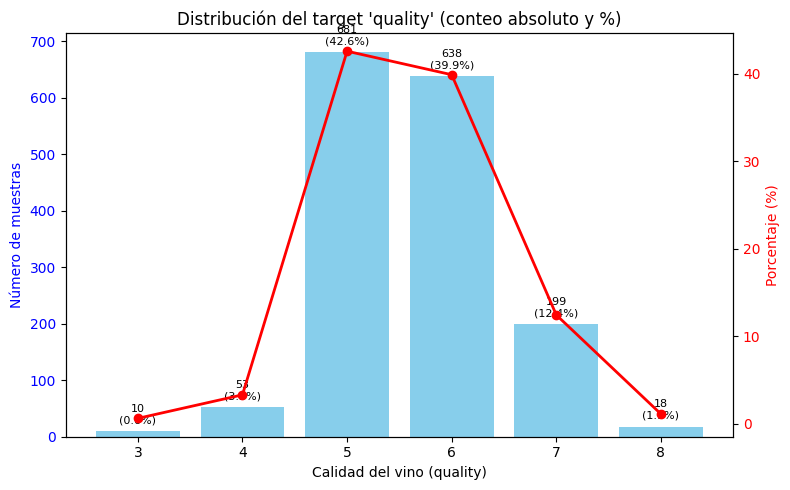

In [30]:
def graficar_distribucion_target():
  # Calcular frecuencias absolutas y relativas
  quality_counts = df["quality"].value_counts().sort_index()
  quality_perc = (quality_counts / quality_counts.sum()) * 100

  # Gráfico de barras con dos ejes (conteo absoluto y %)
  fig, ax1 = plt.subplots(figsize=(8,5))

  # Barras (conteo absoluto)
  bars = ax1.bar(quality_counts.index, quality_counts.values, color="skyblue")
  ax1.set_xlabel("Calidad del vino (quality)")
  ax1.set_ylabel("Número de muestras", color="blue")
  ax1.tick_params(axis="y", labelcolor="blue")

  # Segundo eje Y para porcentajes
  ax2 = ax1.twinx()
  ax2.plot(quality_counts.index, quality_perc.values, color="red", marker="o", linewidth=2)
  ax2.set_ylabel("Porcentaje (%)", color="red")
  ax2.tick_params(axis="y", labelcolor="red")

  # Títulos y ajustes
  plt.title("Distribución del target 'quality' (conteo absoluto y %)")
  plt.xticks(quality_counts.index)

  # Mostrar valores encima de cada barra
  for bar, perc in zip(bars, quality_perc.values):
      height = bar.get_height()
      ax1.text(bar.get_x() + bar.get_width()/2, height+10,
              f"{int(height)}\n({perc:.1f}%)",
              ha="center", va="bottom", fontsize=8)

  plt.tight_layout()
  plt.show()


graficar_distribucion_target()

Revisión del dataset:

* Filas: 1.599

* Columnas: 12 (11 predictoras numéricas continuas + target quality).

* Valores faltantes: Ninguno.

* Tipo de datos: Todo numérico (float en features, int en target).

* Target (quality): valores entre 3 y 8, pero con distribución desbalanceada (la mayoría son 5 y 6).

---

### Preprocesamiento:

#### Manejo de variables predictoras:

Como todos los atributos son numéricos, no se necesita one-hot encoding ni transformaciones categóricas.

Normalización y estandarización: No lo aplicamos en este preprocesamiento general. En la sección propia de cada modelo se analizará si son necesarios para el modelo específico.

Outliers: Vamos detectar y tratar outliers extremos, ya que algunos atributos (residual sugar, chlorides, total sulfur dioxide) tienen colas largas que podrían afectar el aprendizaje.

---
### Outliers


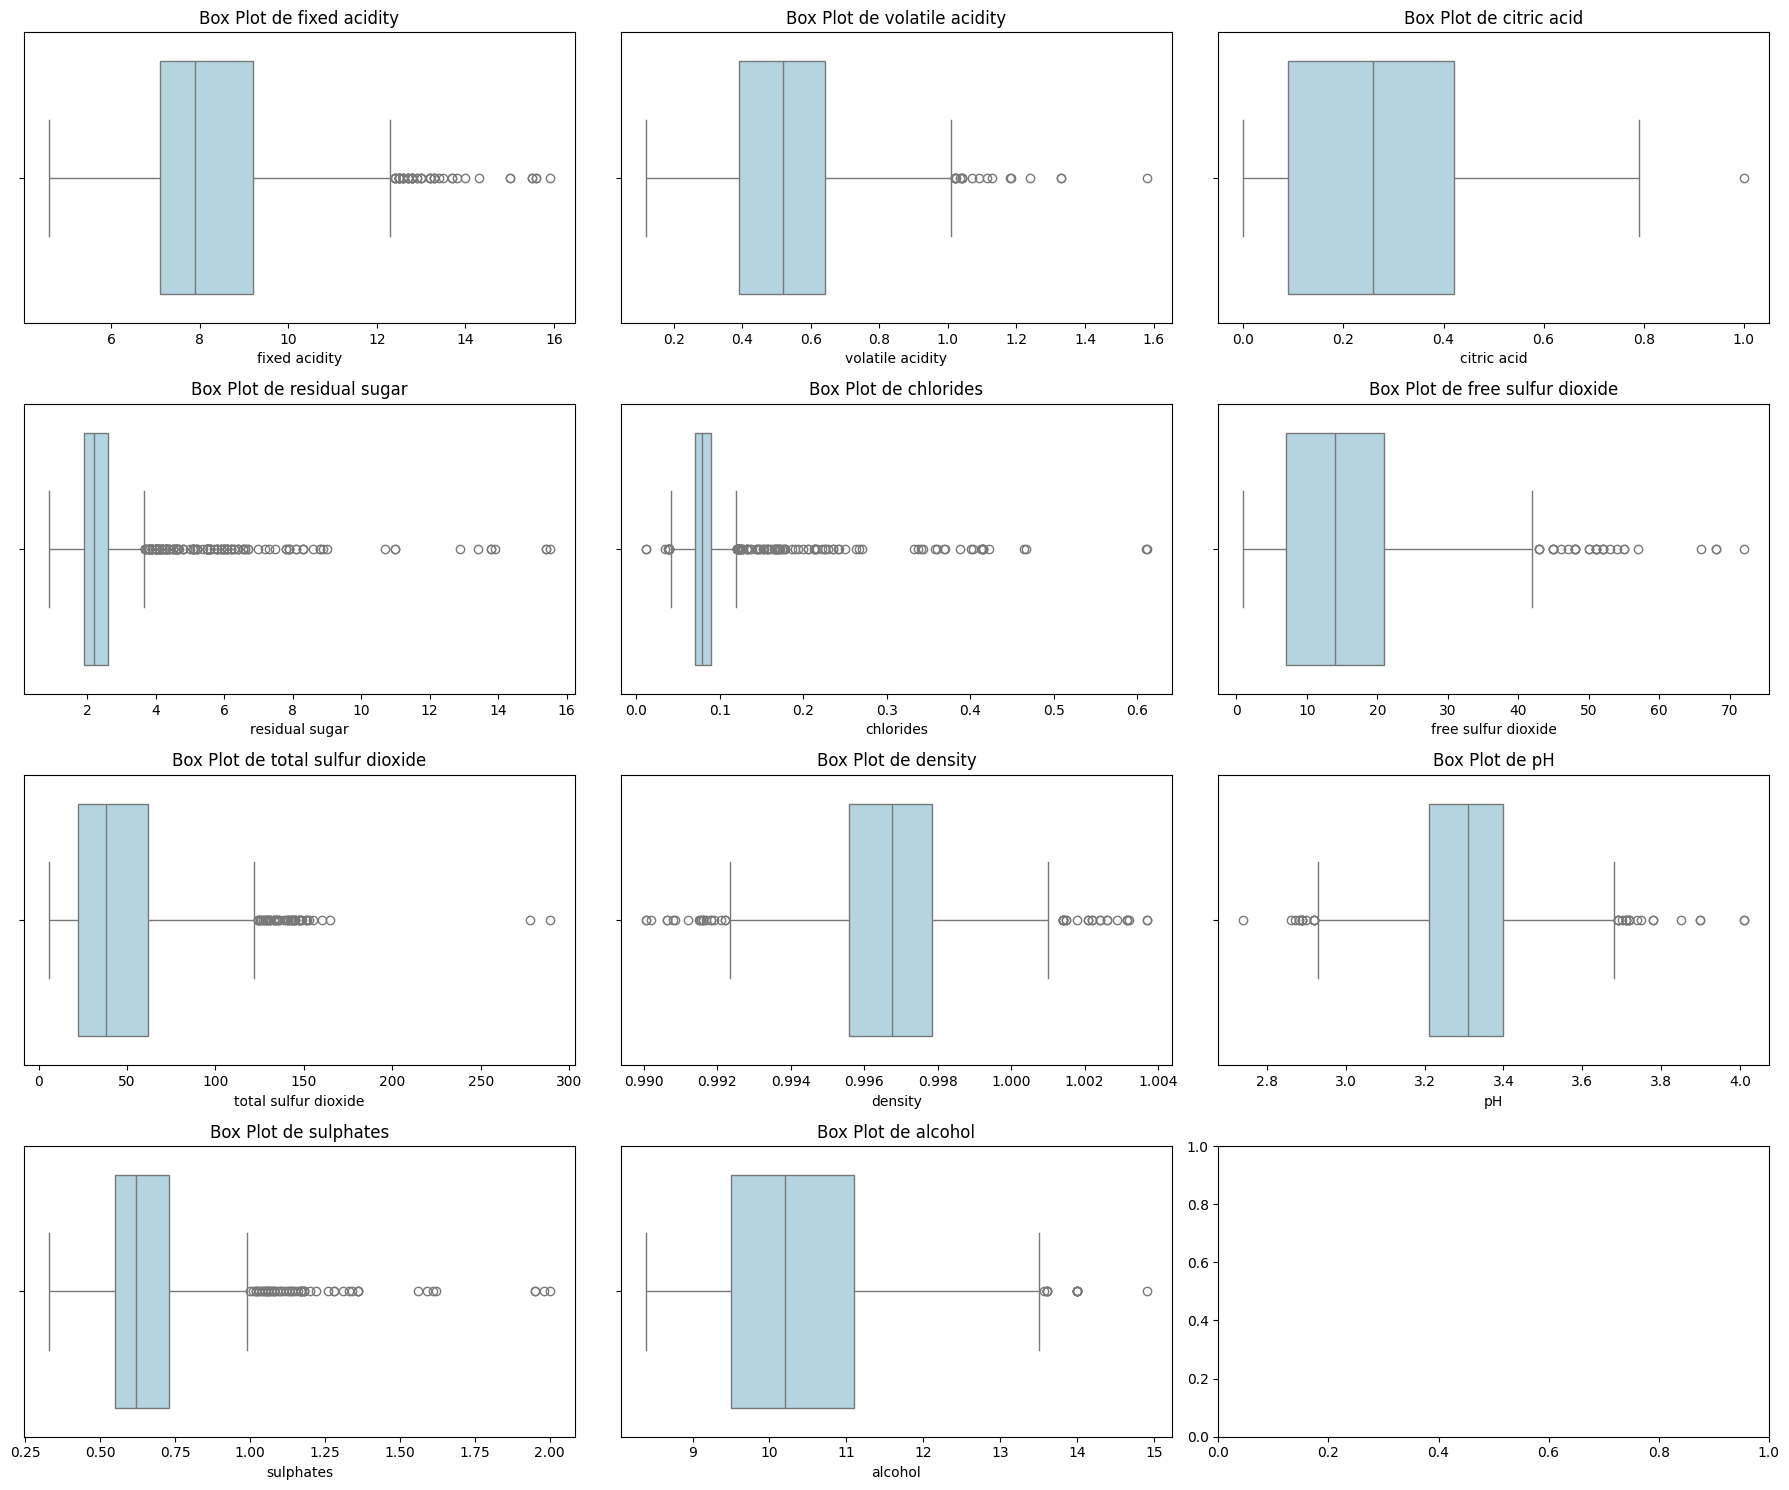

In [31]:
def graficar_outliers():
  features = df.drop('quality', axis=1).columns

  # Crear box plots para identificar valores atípicos
  fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 15))
  axes = axes.flatten()

  for i, col in enumerate(features):
      sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
      axes[i].set_title(f'Box Plot de {col}')

  plt.tight_layout()
  plt.show()


graficar_outliers()

Los box plots confirman visualmente la existencia de numerosos valores atípicos en la mayoría de las variables, especialmente en aquellas con distribuciones asimétricas. La gestión de estos valores atípicos será un tema crucial en la fase de preprocesamiento de datos.

### Correlación

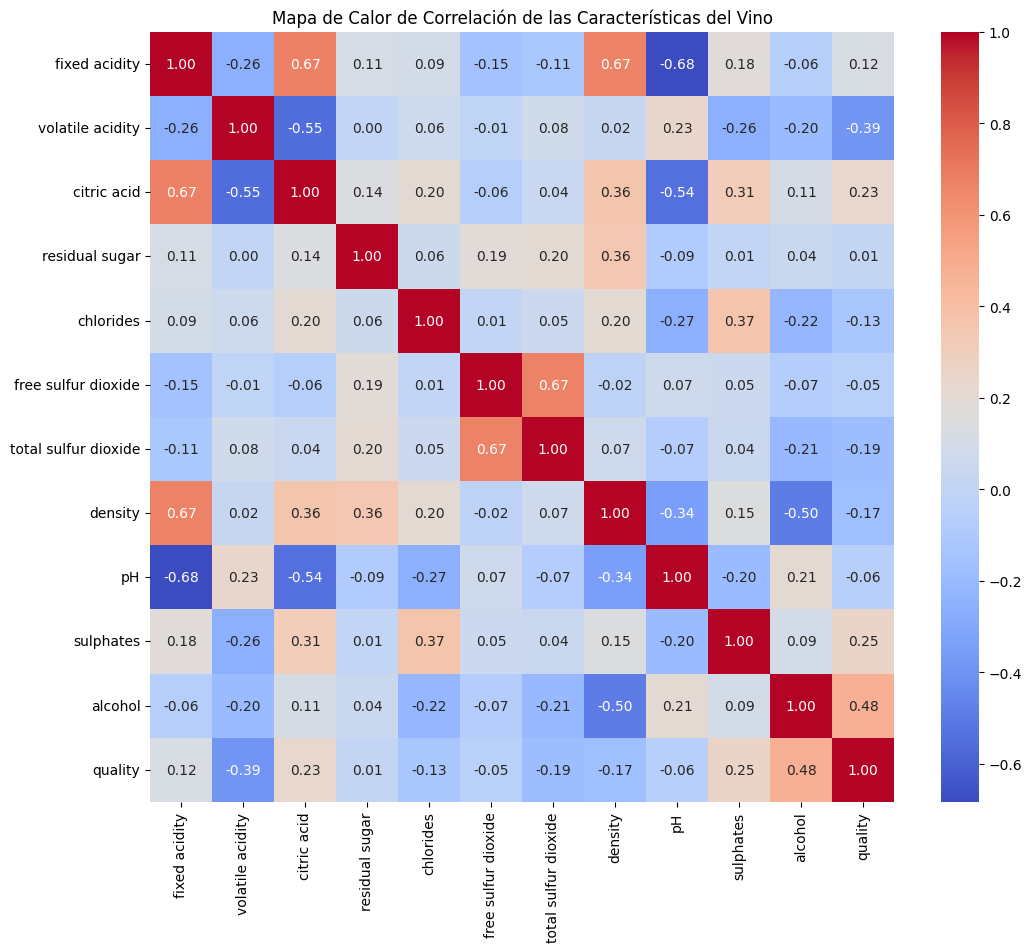

In [32]:
def graficar_correlacion():
    corr_matrix = df.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Mapa de Calor de Correlación de las Características del Vino')
    plt.show()


graficar_correlacion()

#### Correlaciones con la calidad

La variable alcohol muestra la correlación positiva más fuerte con calidad (0.48). Esto podria sugerir que, los vinos con mayor contenido de alcohol tienden a recibir puntuaciones de calidad más altas.

La volatile_acidity presenta la correlación negativa más significativa (-0.39). Esto podria sugerir que, al revez que en caso anterior, mayor es la acidez volatil peor es la calificacion que obtiene el vino.

#### Comportamiento de las features comparadas con los Niveles de Calidad
El boxplot a continuacion, compara la distribución de cada feature para cada nivel de calidad.


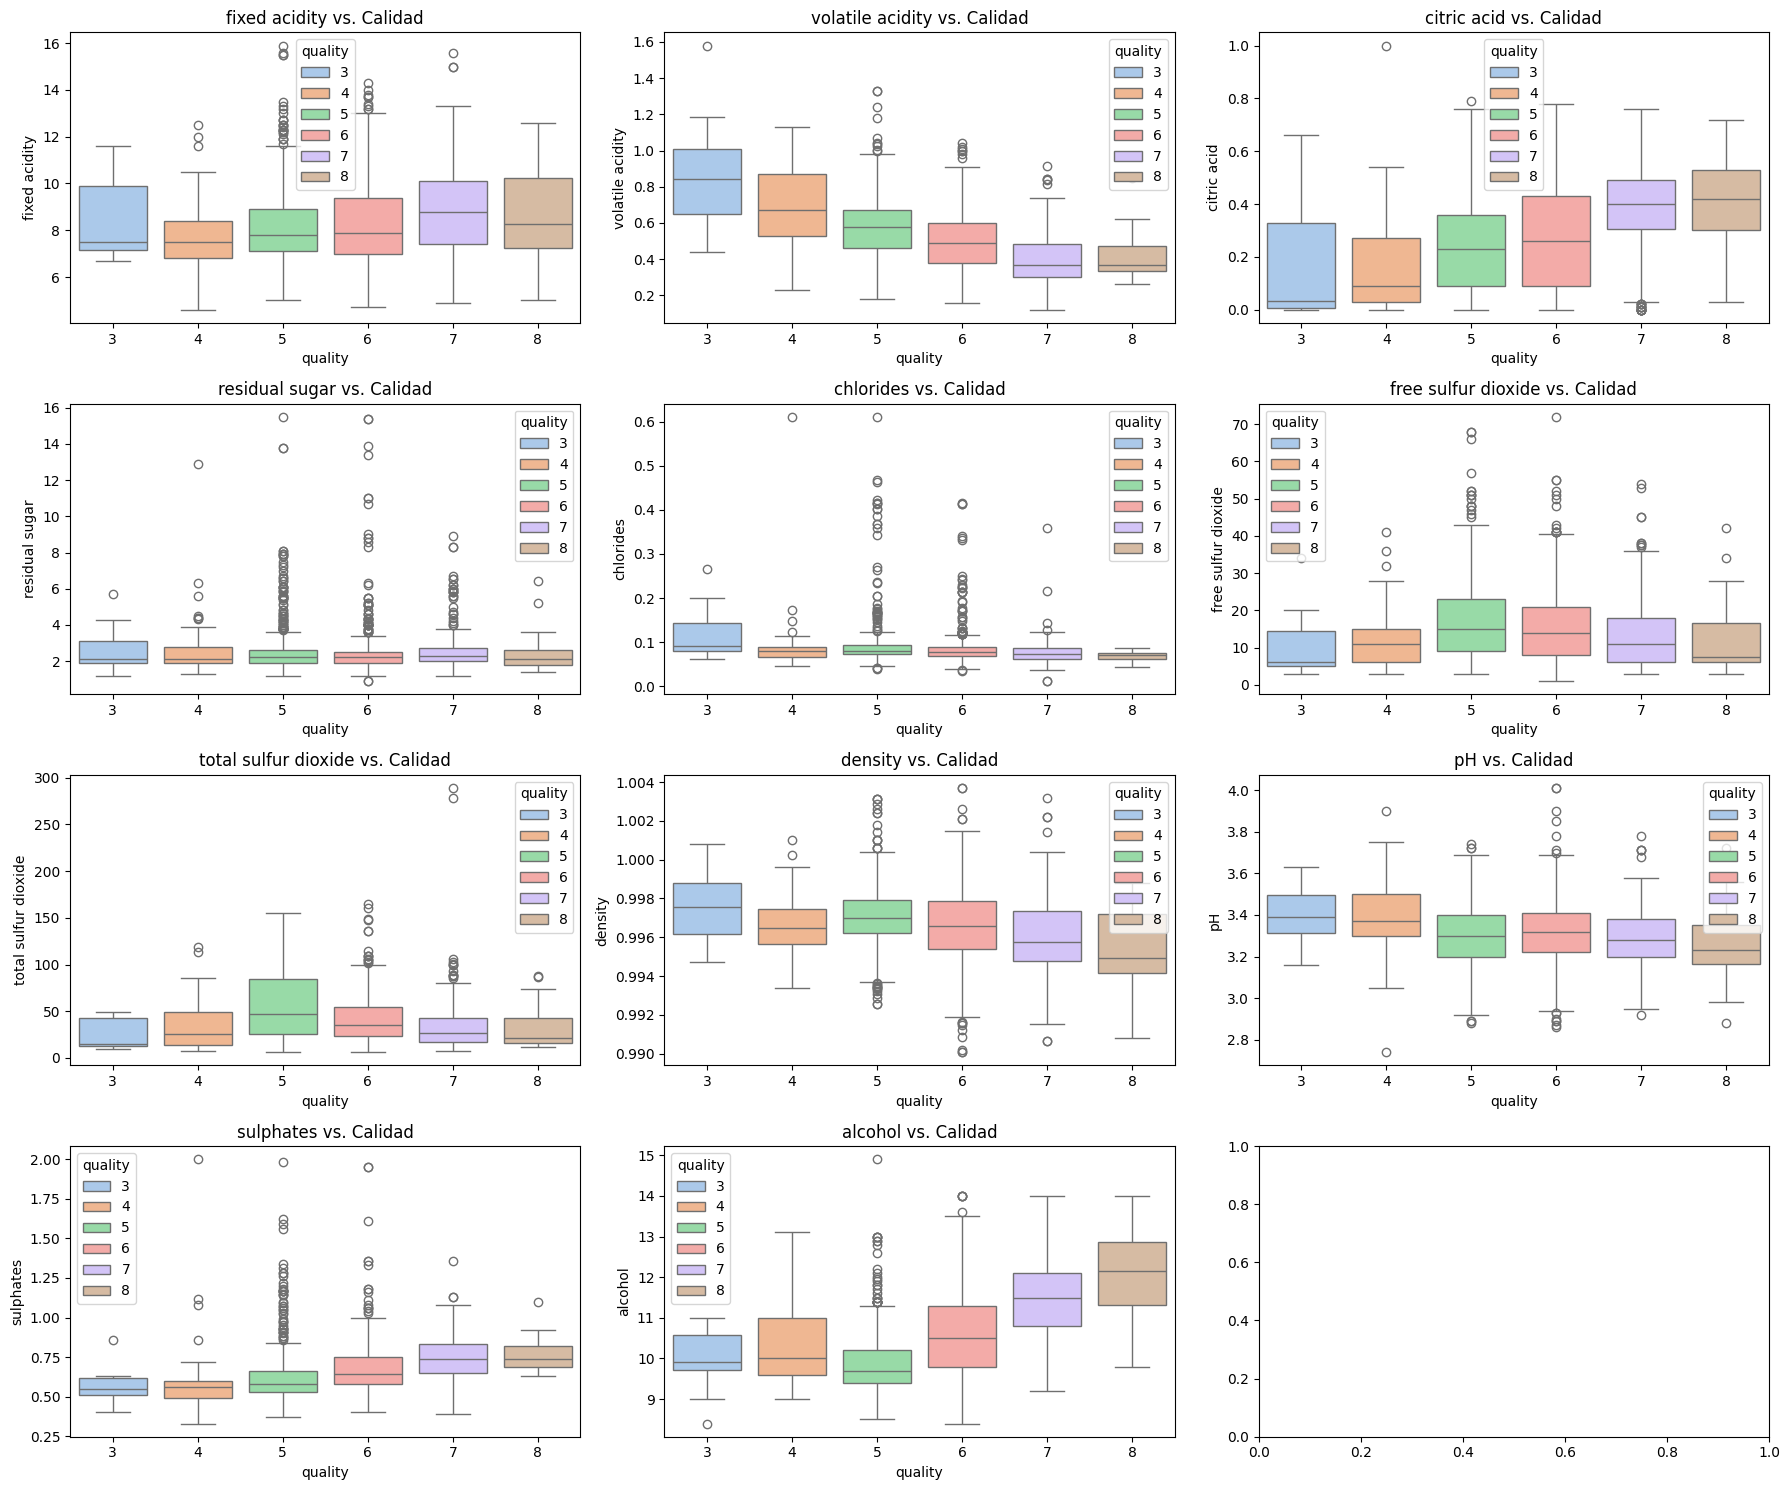

In [34]:
def graficar_features_target():
    features = df.drop('quality', axis=1).columns
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 15))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='pastel', hue='quality')
        axes[i].set_title(f'{col} vs. Calidad')

    plt.tight_layout()
    plt.show()

graficar_features_target()


Algunas obvservaciones claves:

- Se observa una clara tendencia ascendente en la mediana del `alcohol` a medida que aumenta la puntuación de calidad.
- La mediana de `volatile_acidity` muestra una tendencia descendente igualmente clara.
- `citric_acid` y `sulphates` tienden a aumentar con la calidad, aunque con mas variabilidad.
- `density` tiende a disminuir ligeramente a medida que aumenta la calidad.


#### Target - Balanceo de clases:

El dataset está desbalanceado: la mayoría son 5 y 6 (ver gráfico de más arriba).

Vamos a aplicar:

* Estratificación en train/test split.

* Balanceo por peso de las clases (class_weight="balanced").

----

#### Split de datos:

El dataset está muy desbalanceado en su target: muy pocas muestras de las categorías 3, 4, 7 y 8; muchas muestras de las categrías 5 y 6.

Hacemos tres splits diferentes agrupando las categorías del target de diferente manera:
* Split 1: con las categorías como vienen en el dataset.
* Split 2: agrupando las categrías 3 y 4 en una sola (4), las categorías 5 y 6 quedan como están, y agrupando las categorías 7 y 8 en otra (7).
* Split 3: agrupando 3, 4 y 5 en una categoría (5), y las categorías 6, 7 y 8 en otra (6); lo que nos da un target binario.

Hacemos el split estratificado, de modo que la proporción de clases en *quality* se mantenga en train y test:

In [7]:
test_size = 0.3

X = df.drop("quality", axis=1)
y = df["quality"]

# Split 1
y1 = y.copy()
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X,
    y1, 
    test_size=test_size,
    stratify=y1
)

# Split 2
y2 = y.map({3:4, 4:4, 5:5, 6:6, 7:7, 8:7})
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X,
    y2, 
    test_size=test_size,
    stratify=y2
)

# Split 3
y3 = y.map({3:5, 4:5, 5:5, 6:6, 7:6, 8:6})
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X,
    y3, 
    test_size=test_size,
    stratify=y3
)

In [36]:
print("Tamaño X_train:", X1_train.shape)
print("Tamaño X_test:", X1_test.shape)
print("Tamaño y_train:", y1_train.shape)
print("Tamaño y_test:", y1_test.shape)
print("Distribución en train:\n", y1_train.value_counts(normalize=True))
print("Distribución en test:\n", y1_test.value_counts(normalize=True))

Tamaño X_train: (1119, 11)
Tamaño X_test: (480, 11)
Tamaño y_train: (1119,)
Tamaño y_test: (480,)
Distribución en train:
 5    0.426273
6    0.398570
7    0.124218
4    0.033065
8    0.011618
3    0.006256
Name: quality, dtype: float64
Distribución en test:
 5    0.425000
6    0.400000
7    0.125000
4    0.033333
8    0.010417
3    0.006250
Name: quality, dtype: float64


Calculo el peso de las clases de los diferentes splits para luego usar en cada modelo:

In [12]:
classes1 = np.unique(y1_train)
weights1 = compute_class_weight(class_weight='balanced', classes=classes1, y=y1_train)
class_weights1 = dict(zip(classes1, weights1))
print(classes1)
print(class_weights1)

[3 4 5 6 7 8]
{3: 26.642857142857142, 4: 5.04054054054054, 5: 0.3909853249475891, 6: 0.41816143497757846, 7: 1.341726618705036, 8: 14.346153846153847}


In [13]:
classes2 = np.unique(y2_train)
weights2 = compute_class_weight(class_weight='balanced', classes=classes2, y=y2_train)
class_weights2 = dict(zip(classes2, weights2))
print(classes2)
print(class_weights2)

[4 5 6 7]
{4: 6.357954545454546, 5: 0.5864779874213837, 6: 0.6272421524663677, 7: 1.8404605263157894}


In [14]:
classes3 = np.unique(y3_train)
weights3 = compute_class_weight(class_weight='balanced', classes=classes3, y=y3_train)
class_weights3 = dict(zip(classes3, weights3))
print(classes3)
print(class_weights3)

[5 6]
{5: 1.0738963531669865, 6: 0.93561872909699}


---

### Random Forest

Aplicamos este modelo porque es una de las mejores opciones para trabajar con varios parametros que no se relacionan linealmente entre si y con la salida. Al tratarse de vinos, si tomamos de ejemplo la acidez, cierto grado de acidez puede ser el factor clave para alcanzar la excelencia, pero muy ácido sería de mala calidad. 
En este modelo se aplica la técnica de SMOTE en la busqueda de equilibrar el dataset de entrenamiento.

Accuracy del Random Forest: 0.6729166666666667
F1 Macro: 0.3825439807410364

Reporte de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.73      0.76      0.74       204
           6       0.62      0.72      0.67       192
           7       0.67      0.47      0.55        60
           8       1.00      0.20      0.33         5

    accuracy                           0.67       480
   macro avg       0.50      0.36      0.38       480
weighted avg       0.65      0.67      0.66       480



C:\Users\Usuario\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Usuario\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Usuario\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

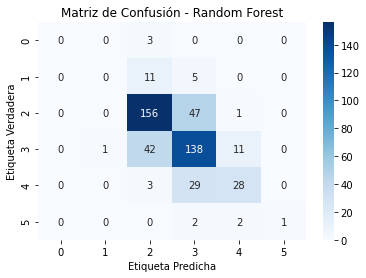

Accuracy del Random Forest: 0.6729166666666667
F1 Macro: 0.5011558240133146

Reporte de Clasificación:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        19
           5       0.71      0.77      0.74       204
           6       0.62      0.69      0.65       192
           7       0.77      0.51      0.61        65

    accuracy                           0.67       480
   macro avg       0.52      0.49      0.50       480
weighted avg       0.65      0.67      0.66       480



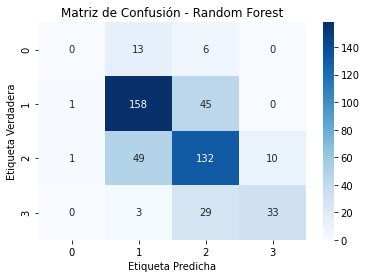

Accuracy del Random Forest: 0.81875
F1 Macro: 0.817990838523529

Reporte de Clasificación:
              precision    recall  f1-score   support

           5       0.80      0.81      0.81       223
           6       0.83      0.82      0.83       257

    accuracy                           0.82       480
   macro avg       0.82      0.82      0.82       480
weighted avg       0.82      0.82      0.82       480



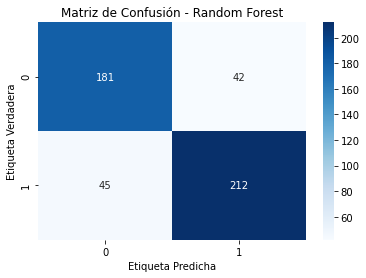

Accuracy del Random Forest: 0.65
F1 Macro: 0.4337175040384915

Reporte de clasificación con SMOTE:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.20      0.25      0.22        16
           5       0.76      0.74      0.75       204
           6       0.65      0.62      0.63       192
           7       0.51      0.62      0.56        60
           8       0.50      0.40      0.44         5

    accuracy                           0.65       480
   macro avg       0.44      0.44      0.43       480
weighted avg       0.66      0.65      0.65       480

Accuracy del Random Forest: 0.64375
F1 Macro: 0.5176472728950945

Reporte de clasificación con SMOTE:
              precision    recall  f1-score   support

           4       0.12      0.11      0.11        19
           5       0.70      0.74      0.72       204
           6       0.63      0.60      0.62       192
           7       0.62      0.62      

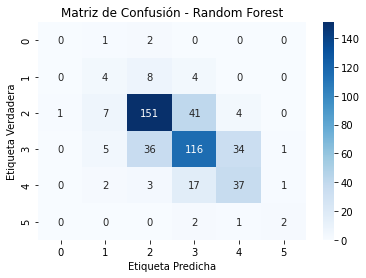

Hiperparametros + SMOTE 4 clases
Accuracy del Random Forest: 0.6333333333333333
F1 Macro: 0.5265180623671404

Reporte de Clasificación:
              precision    recall  f1-score   support

           4       0.14      0.16      0.15        19
           5       0.70      0.70      0.70       204
           6       0.62      0.60      0.61       192
           7       0.64      0.66      0.65        65

    accuracy                           0.63       480
   macro avg       0.52      0.53      0.53       480
weighted avg       0.64      0.63      0.63       480



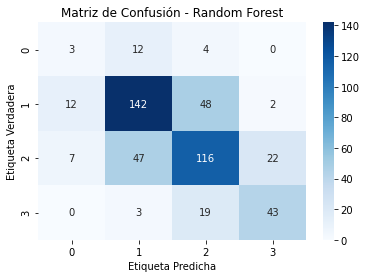

Hiperparametros + sin SMOTE 2 clases
Accuracy del Random Forest: 0.8208333333333333
F1 Macro: 0.8199298563975501

Reporte de Clasificación:
              precision    recall  f1-score   support

           5       0.81      0.81      0.81       223
           6       0.83      0.83      0.83       257

    accuracy                           0.82       480
   macro avg       0.82      0.82      0.82       480
weighted avg       0.82      0.82      0.82       480



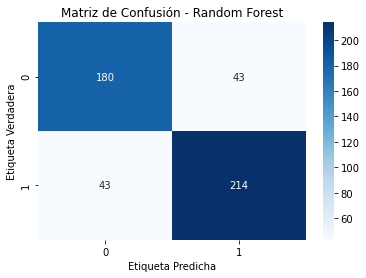

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Hacer modelado y las predicciones con n_estimators=100 y las 6 clases
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights1)
modelo_rf.fit(X1_train, y1_train)
y_pred_rf = modelo_rf.predict(X1_test)
print("Accuracy del Random Forest:", accuracy_score(y1_test, y_pred_rf))
print("F1 Macro:", f1_score(y1_test, y_pred_rf, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y1_test, y_pred_rf))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf = confusion_matrix(y1_test, y_pred_rf)
sns.heatmap(mat_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

# Hacer modelado y las predicciones con n_estimators=100 y las 4 clases
modelo_rf2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights2)
modelo_rf2.fit(X2_train, y2_train)
y2_pred_rf = modelo_rf2.predict(X2_test)
# Evaluar el modelo
print("Accuracy del Random Forest:", accuracy_score(y2_test, y2_pred_rf))
print("F1 Macro:", f1_score(y2_test, y2_pred_rf, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y2_test, y2_pred_rf))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf2 = confusion_matrix(y2_test, y2_pred_rf)
sns.heatmap(mat_rf2, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

# Hacer modelado y las predicciones con n_estimators=100 y las 2 clases
modelo_rf3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights3)
modelo_rf3.fit(X3_train, y3_train)
y3_pred_rf = modelo_rf3.predict(X3_test)
print("Accuracy del Random Forest:", accuracy_score(y3_test, y3_pred_rf))
print("F1 Macro:", f1_score(y3_test, y3_pred_rf, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y3_test, y3_pred_rf))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf3 = confusion_matrix(y3_test, y3_pred_rf)
sns.heatmap(mat_rf3, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()



#Utilizo SMOTE para crear datos muy parecidos a los que existentes de las clases con menos datos para analizar mejora

from imblearn.over_sampling import SMOTE # <-- Importamos SMOTE

# Creamos y aplicamos SMOTE SOLO al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X1_train, y1_train)

# Entrenamos el modelo con los datos remuestreados
# Nota: Ya no es necesario usar class_weight, porque los datos ya están balanceados
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_resampled, y_train_resampled)
# Evaluamos el modelo en el conjunto de prueba ORIGINAL
y_pred_smote = rf_smote.predict(X1_test)
print("Accuracy del Random Forest:", accuracy_score(y1_test, y_pred_smote))
print("F1 Macro:", f1_score(y1_test, y_pred_smote, average='macro'))
print("\nReporte de clasificación con SMOTE:")
print(classification_report(y1_test, y_pred_smote))

X2_train_resampled, y2_train_resampled = smote.fit_resample(X2_train, y2_train)
rf_smote2 = RandomForestClassifier(random_state=42)
rf_smote2.fit(X2_train_resampled, y2_train_resampled)
y2_pred_smote = rf_smote2.predict(X2_test)
print("Accuracy del Random Forest:", accuracy_score(y2_test, y2_pred_smote))
print("F1 Macro:", f1_score(y2_test, y2_pred_smote, average='macro'))
print("\nReporte de clasificación con SMOTE:")
print(classification_report(y2_test, y2_pred_smote))

X3_train_resampled, y3_train_resampled = smote.fit_resample(X3_train, y3_train)
rf_smote3 = RandomForestClassifier(random_state=42)
rf_smote3.fit(X3_train_resampled, y3_train_resampled)
y3_pred_smote = rf_smote3.predict(X3_test)
print("Accuracy del Random Forest:", accuracy_score(y3_test, y3_pred_smote))
print("F1 Macro:", f1_score(y3_test, y3_pred_smote, average='macro'))
print("\nReporte de clasificación con SMOTE:")
print(classification_report(y3_test, y3_pred_smote))



#Hiperparámetros
from sklearn.model_selection import RandomizedSearchCV

# Definición del espacio de parámetros
param_grid_expanded = {
     # Nos centramos alrededor de 300
    'n_estimators': [100, 150, 200, 250, 350],
    # Nos centramos alrededor de 30
    'max_depth': [20,25, 30],
    # Ya sabemos que prefiere los valores bajos, dejamos solo los mejores
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    # Mantenemos las otras opciones
    'max_features': ['sqrt', 'log2'],
    'criterion': ['entropy'] # Ya sabemos que 'entropy' funcionó mejor    
}

# Creación del modelo base
rf = RandomForestClassifier(random_state=42)

# Configuración de la búsqueda con más iteraciones
rf_random_expanded = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_expanded, # Usamos la nueva grilla
    n_iter=100,                              # Aumentamos de 50 a 100 iteraciones
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

rf_random_expanded.fit(X_train_resampled, y_train_resampled)

# Muestra de los nuevos mejores parámetros
print("Nuevos mejores parámetros:", rf_random_expanded.best_params_)

best_model_expanded = rf_random_expanded.best_estimator_

rf_random_expanded2 = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_expanded, # Usamos la nueva grilla
    n_iter=100,                              # Aumentamos de 50 a 100 iteraciones
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

rf_random_expanded2.fit(X2_train_resampled, y2_train_resampled)
print("Nuevos mejores parámetros:", rf_random_expanded2.best_params_)
best_model_expanded2 = rf_random_expanded2.best_estimator_

rf_random_expanded3 = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_expanded, # Usamos la nueva grilla
    n_iter=100,                              # Aumentamos de 50 a 100 iteraciones
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
rf_random_expanded3.fit(X3_train, y3_train)
print("Nuevos mejores parámetros:", rf_random_expanded3.best_params_)
best_model_expanded3 = rf_random_expanded3.best_estimator_

print("Hiperparametros + SMOTE 6 clases")
y_pred_rf_best = best_model_expanded.predict(X1_test)
print("Accuracy del Random Forest:", accuracy_score(y1_test, y_pred_rf_best))
print("F1 Macro:", f1_score(y1_test, y_pred_rf_best, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y1_test, y_pred_rf_best))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf_best = confusion_matrix(y1_test, y_pred_rf_best)
sns.heatmap(mat_rf_best, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

y2_pred_rf_best = best_model_expanded2.predict(X2_test)
print("Hiperparametros + SMOTE 4 clases")
print("Accuracy del Random Forest:", accuracy_score(y2_test, y2_pred_rf_best))
print("F1 Macro:", f1_score(y2_test, y2_pred_rf_best, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y2_test, y2_pred_rf_best))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf_best2 = confusion_matrix(y2_test, y2_pred_rf_best)
sns.heatmap(mat_rf_best2, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

y3_pred_rf_best = best_model_expanded3.predict(X3_test)
print("Hiperparametros + sin SMOTE 2 clases")
print("Accuracy del Random Forest:", accuracy_score(y3_test, y3_pred_rf_best))
print("F1 Macro:", f1_score(y3_test, y3_pred_rf_best, average='macro'))
print("\nReporte de Clasificación:")
print(classification_report(y3_test, y3_pred_rf_best))

# Matriz de confusión para visualizar mejor el rendimiento
mat_rf_best3 = confusion_matrix(y3_test, y3_pred_rf_best)
sns.heatmap(mat_rf_best3, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

La mejor predicción es al hacer 2 grupos. Esto me permite saber si el vino es de gama media-alta o media-baja, teniendo sentido para el dueño de la bodega para saber si vende su vino con un precio popular o si vale la pena conbocar a un somelier para categorizar su vino en el top de gama. 

---

### K-Nearest Neighbors

A continuación se aplica el algoritmo K-Nearest Neighbors (KNN) al dataset Wine Quality (red wine) con el fin de predecir la calidad del vino a partir de variables fisicoquímicas. Se evalúa el rendimiento del algoritmo para distintos valores de k mediante validación cruzada, analizando métricas de clasificación y matrices de confusión. Además, se explora reagrupar clases poco frecuentes para mejorar el accuracy dado el nivel de desbalance de datos.

El enfoque de KNN permite distinguir razonablemente bien los vinos de calidad media (5–7), pero resulta poco confiable para identificar clases raras. Aunque el reagrupamiento de etiquetas mejora levemente el macro average (promedio no ponderado), no ayuda a resolver la falta de accuracy causada por el desbalance de clases.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [3 4 5 6 7 8]
class_weights: {np.int64(3): np.float64(26.65), np.int64(4): np.float64(5.028301886792453), np.int64(5): np.float64(0.39133627019089573), np.int64(6): np.float64(0.4177115987460815), np.int64(7): np.float64(1.3391959798994975), np.int64(8): np.float64(14.805555555555555)}
Mejor k: 12 con accuracy de validación cruzada: 0.6669

Reporte de clasificación:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.73      0.70      0.71       136
           6       0.60      0.72      0.65       128
           7       0.62      0.53      0.57        40
           8       0.50      0.33      0.40         3

    accuracy                           0.65       320
   macro avg       0.41      0.38      0.39       320
weighted avg   

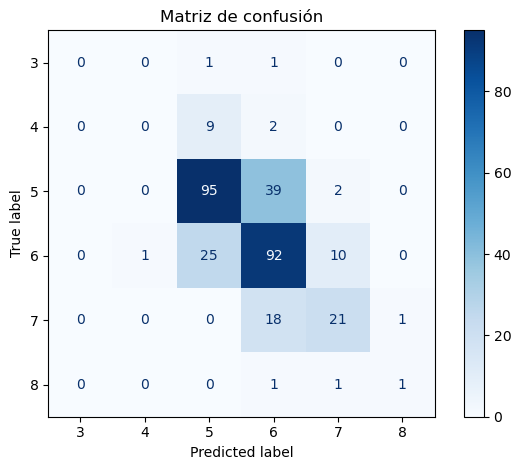

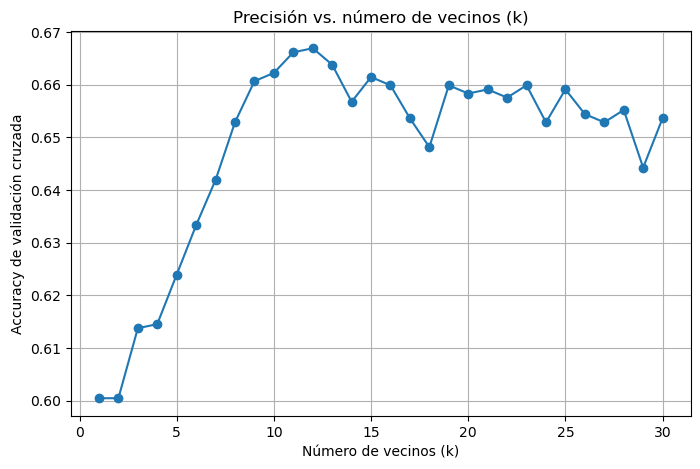

In [3]:

def K_Nearest_Neighbors(X_train, X_test, y_train, y_test, classes, class_weights, k_grid=range(1, 31), cv=5, weights='distance', metric='minkowski', p=2):
    print("K NEAREST NEIGHBORS")
    print("Tamaño X_train:", X_train.shape)
    print("Tamaño X_test:", X_test.shape)
    print("Tamaño y_train:", y_train.shape)
    print("Tamaño y_test:", y_test.shape)
    print("classes:", classes)
    print("class_weights:", class_weights)

    # Escalado
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Buscar el mejor k
    cv_scores = []
    for k in k_grid:
        knn_k = KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric, p=p)
        score = cross_val_score(knn_k, X_train_s, y_train, cv=cv, scoring='accuracy').mean()
        cv_scores.append(score)
    best_idx = int(np.argmax(cv_scores))
    best_k = list(k_grid)[best_idx]
    best_cv = cv_scores[best_idx]
    print(f"Mejor k: {best_k} con accuracy de validación cruzada: {best_cv:.4f}")

    # Entrenamiento final
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=weights, metric=metric, p=p)
    knn.fit(X_train_s, y_train)

    # Evaluación
    y_pred = knn.predict(X_test_s)
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    print("Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):\n", cm)

    # Matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Matriz de confusión")
    plt.tight_layout()
    plt.show()
    
    # k v/s accuracy
    plt.figure(figsize=(8,5))
    plt.plot(list(k_grid), cv_scores, marker="o")
    plt.xlabel("Número de vecinos (k)")
    plt.ylabel("Accuracy de validación cruzada")
    plt.title("Precisión vs. número de vecinos (k)")
    plt.grid(True)
    plt.show()



    return {
        "scaler": scaler,
        "model": knn,
        "best_k": best_k,
        "best_cv": best_cv,
        "cv_scores": cv_scores,
        "classes": classes,
        "confusion_matrix": cm,
        "y_pred": y_pred
    }

# 1) Cargar los datos
df = pd.read_csv('dataset/winequality-red.csv')

# 2) Separar X e y
X = df.drop('quality', axis=1)
y = df['quality']

# 3) División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# calcular pesos de las clases
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, class_weights))

# 4) Llamar a la función final
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 31),   # probar k=1..30
    cv=5,
    weights='distance'     
)


K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [4 5 6 7]
class_weights: {np.int64(4): np.float64(6.345238095238095), np.int64(5): np.float64(0.5870044052863436), np.int64(6): np.float64(0.6265673981191222), np.int64(7): np.float64(1.8421658986175116)}
Mejor k: 27 con accuracy de validación cruzada: 0.6873

Reporte de clasificación:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00        13
           5       0.69      0.72      0.71       136
           6       0.61      0.65      0.63       128
           7       0.68      0.65      0.67        43

    accuracy                           0.65       320
   macro avg       0.49      0.51      0.50       320
weighted avg       0.63      0.65      0.64       320

Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):
 [[ 0 11  2  0]
 [ 0 98 37  1]
 [ 0 33 83 12]
 [ 0  0 15 28

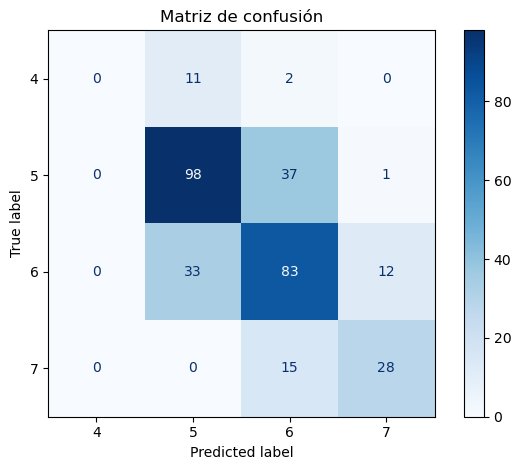

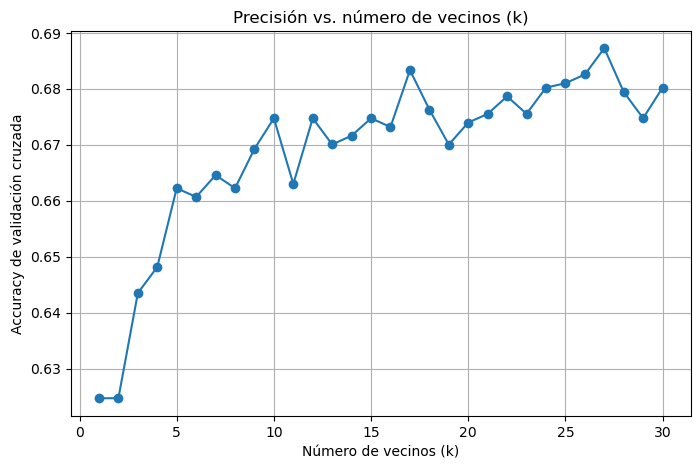

In [4]:
y = y.map({3:4, 4:4, 5:5, 6:6, 7:7, 8:7})

# 3) División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# calcular pesos de las clases
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, class_weights))

# 4) Llamar a la función final
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 31),   # probar k=1..30
    cv=5,
    weights='distance'     
)

¿Seguirá subiendo el Accuracy con más vecinos?

K NEAREST NEIGHBORS
Tamaño X_train: (1279, 11)
Tamaño X_test: (320, 11)
Tamaño y_train: (1279,)
Tamaño y_test: (320,)
classes: [4 5 6 7]
class_weights: {np.int64(4): np.float64(6.345238095238095), np.int64(5): np.float64(0.5870044052863436), np.int64(6): np.float64(0.6265673981191222), np.int64(7): np.float64(1.8421658986175116)}
Mejor k: 27 con accuracy de validación cruzada: 0.6873

Reporte de clasificación:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00        13
           5       0.69      0.72      0.71       136
           6       0.61      0.65      0.63       128
           7       0.68      0.65      0.67        43

    accuracy                           0.65       320
   macro avg       0.49      0.51      0.50       320
weighted avg       0.63      0.65      0.64       320

Matriz de confusión (filas=verdadero, columnas=predicho, etiquetas en orden de 'classes'):
 [[ 0 11  2  0]
 [ 0 98 37  1]
 [ 0 33 83 12]
 [ 0  0 15 28

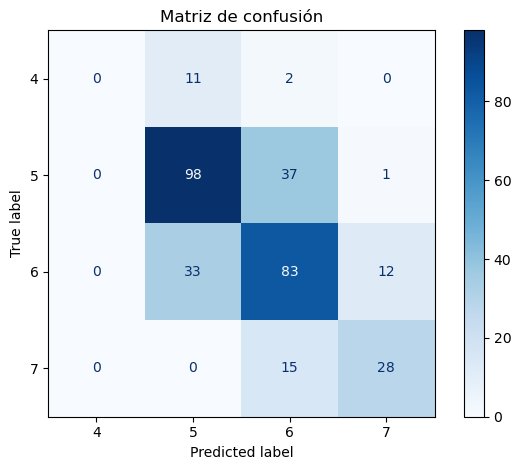

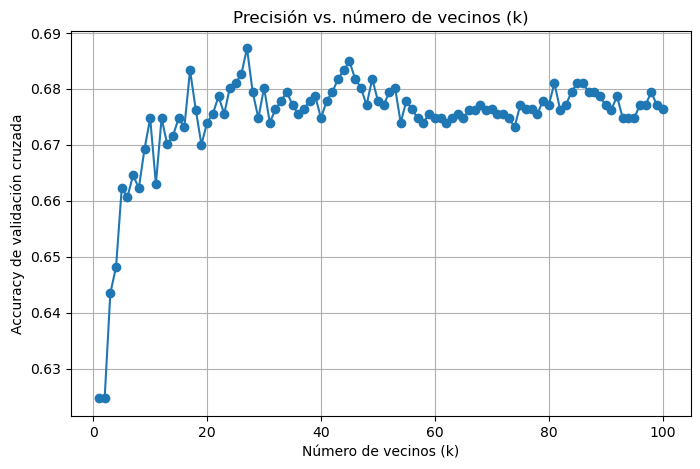

In [5]:
artifacts = K_Nearest_Neighbors(
    X_train, X_test, y_train, y_test,
    classes=classes,
    class_weights=class_weights,
    k_grid=range(1, 101),   # probar k=1..100
    cv=5,
    weights='distance'     
)


No, se mantiene el mismo valor.


Lo que nos interesaba mejorar era Accuracy, pero esto no se pudo lograr ni agrupando de diferente manera ni aumentando k. Con las primeras clases, el número óptimo de vecinos fue k = 12 y Accuray = 0,65. La matriz de confusión y el reporte de clasificación muestran que las clases poco frecuentes (3, 4 y 8) casi nunca fueron predichas correctamente, con precisión y recall bajos o cero.

En las clases más frecuentes (5 y 6) el algoritmo logra precisiones y recalls en torno a 0,6–0,7. Después de reagrupar clases 3 y 4 en 4, y 7 y 8 en 7; el valor óptimo pasó a ser k = 27, manteniendo el mismo Accuracy. La nueva matriz de confusión muestra que los valores de la diagonal de las clases del medio pasaron de 95 y 92 a 98 y 83. El modelo sigue teniendo dificultades con clases poco representadas, como la 4.

La curva de Accuracy vs. k se estabiliza alrededor del mejor valor, lo que sugiere que el desempeño del modelo no es muy sensible a cambios en k una vez alcanzado el número de vecinos óptimo. Ambas matrices de confusión confirman que KNN es más efectivo para las clases mayoritarias, pero tiene problemas con las clases extremas o poco frecuentes. 

---

### Logistic Regression (multiclase)

Para optimizar el modelo de regresión logística, se diseñó un pipeline con dos pasos de preprocesamiento opcionales: un `OutlierClipper` (ver carpet lib) para tratar valores atípicos y un `StandardScaler` para la estandarización de features. Utilizando GridSearchCV, se evaluaron sistemáticamente todas las combinaciones posibles, aplicando ambos transformadores, solo uno, o ninguno, con el fin de determinar que preparación de los datos maximizaba el rendimiento del modelo, medido a través del F1-score ponderado.

Este enfoque permitió comparar directamente los resultados de las tres estrategias. Al revisar los F1-scores y los mejores parámetros encontrados para cada uno de los tres mapeos de la variable objetivo, se pudo identificar de manera concluyente qué combinación global, considerando tanto el preprocesamiento de las features como la representación de la clase.

In [15]:
pipeline = Pipeline([
    ('aplanador', OutlierClipper()),
    ('escalador', StandardScaler()),
    ('modelo', LogisticRegression(solver='lbfgs', random_state=42, max_iter=10000))
])

parametros_grid = {
    'aplanador': [OutlierClipper(), None], # El clipper esta definido en lib/transformers.py
    'escalador': [StandardScaler(), None]
}


# A continuacion, los resultados de correr el modelo con los 3 diferentes mapeos de la variable target

#Mejores parámetros encontrados usando los datos sin mapear
# {'aplanador': OutlierClipper(), 'escalador': StandardScaler()}
# Mejor F1-score (weighted) durante la validación cruzada: 0.5778

#Mejores parámetros encontrados usando 4 clases 
#{'aplanador': OutlierClipper(), 'escalador': None}
#Mejor F1-score (weighted) durante la validación cruzada: 0.5680

#Mejores parámetros encontrados usando 2 clases (malo, bueno)
#{'aplanador': None, 'escalador': StandardScaler()}
#Mejor F1-score (weighted) durante la validación cruzada: 0.7542


grid_search = GridSearchCV(pipeline, parametros_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X1_train, y1_train)

print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

print(f"\nMejor F1-score (weighted) durante la validación cruzada: {grid_search.best_score_:.4f}")

Mejores parámetros encontrados:
{'aplanador': OutlierClipper(), 'escalador': StandardScaler()}

Mejor F1-score (weighted) durante la validación cruzada: 0.5778


In [16]:
mejor_modelo_final = grid_search.best_estimator_

# Entrenar el modelo con los datos de entrenamiento escalados
predicciones = mejor_modelo_final.predict(X1_test)
print("\n--- Reporte de Clasificación en Test con el Mejor Modelo ---")
print(classification_report(y1_test, predicciones))


--- Reporte de Clasificación en Test con el Mejor Modelo ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.06      0.10        16
           5       0.70      0.75      0.72       204
           6       0.57      0.62      0.59       192
           7       0.42      0.35      0.38        60
           8       0.00      0.00      0.00         5

    accuracy                           0.61       480
   macro avg       0.32      0.30      0.30       480
weighted avg       0.59      0.61      0.60       480



Para evaluar la sensibilidad de la regresión logística a la escala de las variables, se experimentó con distintas configuraciones de preprocesamiento. Mediante `GridSearchCV`, se probó sistemáticamente el impacto de utilizar un `OutlierClipper` para tratar valores atípicos y un `StandardScaler` para la estandarización. Esta búsqueda se realizó para determinar qué combinación de transformadores ofrecía el mejor rendimiento en nuestro dataset, que se caracteriza por tener clases muy desbalanceadas.

El principal desafío del dataset es su desequilibrio: la mayoría de los vinos son de calidad media, mientras que las calidades muy altas o bajas son escasas. Para abordar esto, se adoptó una estrategia de remapeo de la variable objetivo, ejecutando el análisis en tres escenarios: uno con las clases originales, otro agrupado en cuatro categorías y un último modelo binario (calidad "Buena" vs. "Mala"). Para cada escenario, `GridSearchCV` identificó la cadena de preprocesamiento óptima.

La evaluación final en el conjunto de prueba, utilizando el `f1-score weighted avg` como métrica principal. El modelo binario fue notablemente superior, alcanzando un F1 de `0.72`, en contraste con el `0.59` del modelo de cuatro clases y el `0.60` del original. Como nota final, se exploró una transformación logarítmica `(log(x+1))` que no mejoró los resultados, por lo que se optó por el pipeline más simple.

---

### Gradient Boosting

Probamos este modelo con este dataset para entender si un modelo basado en árboles puede capturar las relaciones no lineales.

Evaluamos Gradient Boosting con el split 1: las categorías como vienen en el dataset (seis categorías: 3, 4, 5, 6, 7, 8).


Comenzando Gradient Boosting ...

Comenzando entrenamiento ...

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Entrenamiento finalizado.

Mejores hiperparámetros:
{'learning_rate': 0.05, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}

Resultados en test:
   Accuracy: 0.5604
   F1 macro: 0.4347

Classification Report:
              precision    recall  f1-score   support

           3      0.333     0.333     0.333         3
           4      0.156     0.312     0.208        16
           5      0.708     0.667     0.687       204
           6      0.562     0.474     0.514       192
           7      0.395     0.567     0.466        60
           8      0.400     0.400     0.400         5

    accuracy                          0.560       480
   macro avg      0.426     0.459     0.435       480
weighted avg      0.587     0.560     0.569       480



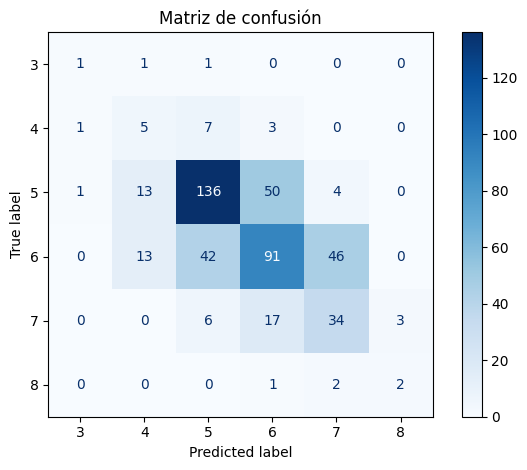


Primeros 10 features por importancia:
volatile acidity        0.175038
alcohol                 0.162003
sulphates               0.125474
density                 0.100622
citric acid             0.087610
total sulfur dioxide    0.070586
pH                      0.061635
fixed acidity           0.061052
residual sugar          0.057010
chlorides               0.056328
dtype: float64


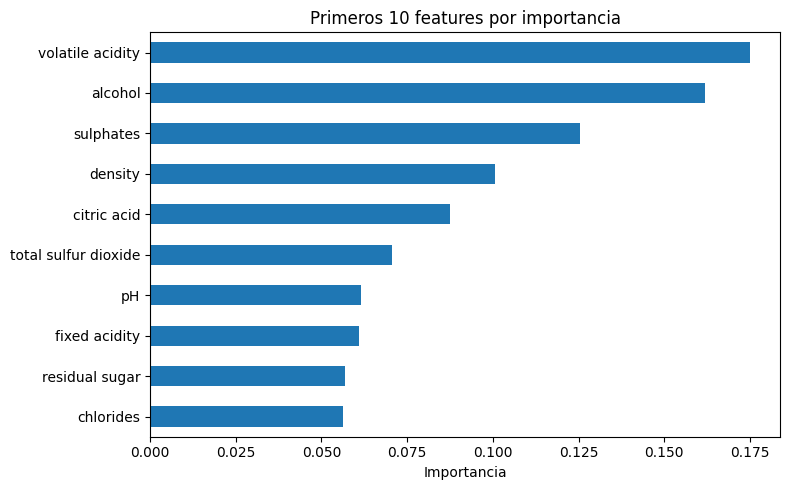


Gradient Boosting finalizado.



In [40]:
if EJECUTAR_GRADIENT_BOOSTING:
  importlib.reload(gbm)
  gradient_boosting_model = gbm.GradientBoostingModel(X1_train.copy(), X1_test.copy(), y1_train.copy(), y1_test.copy(), classes1.copy(), class_weights1.copy())
  gradient_boosting_model.procesar()

Accuracy:
   * El modelo acierta poco más de la mitad de los vinos.
   * Esto está en línea con lo esperado para este dataset.
   * El modelo logra cierta capacidad predictiva, lejos de una buena clasificación para todas las clases.


F1 macro:
   * Penaliza el bajo desempeño en clases minoritarias (calidades 3, 4 y 8).
   * El modelo tiende a favorecer las clases mayoritarias (5 y 6), las minoritarias se predicen mal o casi no se predicen.


Impacto del desbalance:
   * El desbalance fuerte entre categorías explica las limitaciones.
   * Se aplicó balanceo de clases en el entrenamiento, pero este sigue siendo un problema.

Hiperparámetros:
   * Los hiperparámetros óptimos muestran que el modelo funciona mejor con árboles poco profundos y regularizados, que podría deberse a que la señal predictiva es débil y que árboles más complejos llevan a sobreajuste.

Ahora evaluamos Gradient Boosting con el split 2: agrupando las categrías 3 y 4 en una sola (4), las categorías 5 y 6 quedan como están, y agrupando las categorías 7 y 8 en otra (7).


Comenzando Gradient Boosting ...

Comenzando entrenamiento ...

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Entrenamiento finalizado.

Mejores hiperparámetros:
{'learning_rate': 0.05, 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.9}

Resultados en test:
   Accuracy: 0.6042
   F1 macro: 0.5218

Classification Report:
              precision    recall  f1-score   support

           4      0.280     0.368     0.318        19
           5      0.747     0.681     0.713       204
           6      0.584     0.562     0.573       192
           7      0.429     0.554     0.483        65

    accuracy                          0.604       480
   macro avg      0.510     0.542     0.522       480
weighted avg      0.620     0.604     0.610       480



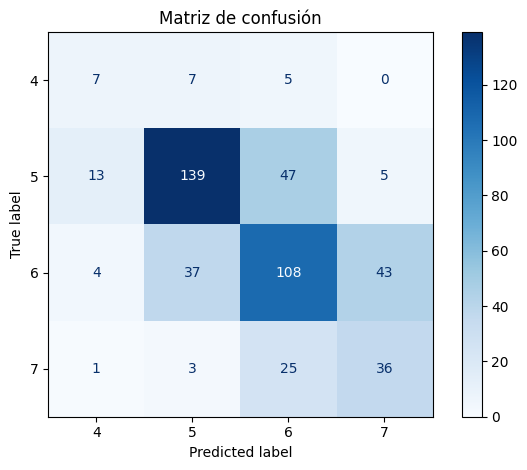


Primeros 10 features por importancia:
alcohol                 0.222081
sulphates               0.164356
volatile acidity        0.156842
total sulfur dioxide    0.083956
residual sugar          0.081264
citric acid             0.060694
pH                      0.057550
fixed acidity           0.053068
chlorides               0.051939
density                 0.042038
dtype: float64


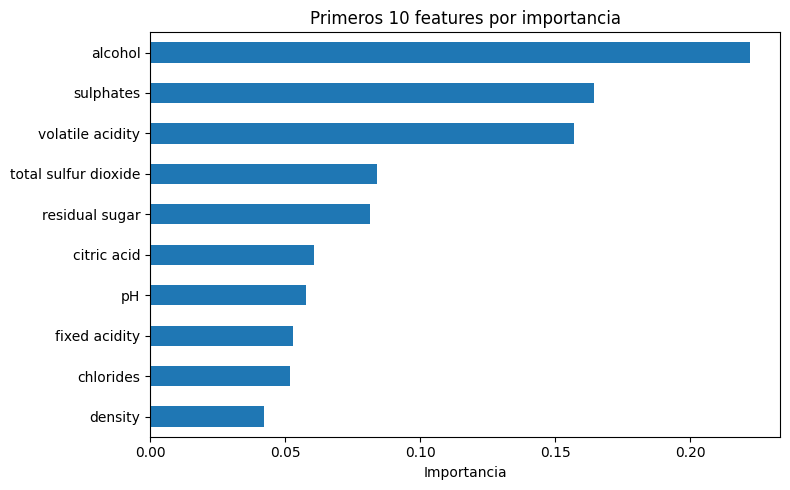


Gradient Boosting finalizado.



In [41]:
if EJECUTAR_GRADIENT_BOOSTING:
  importlib.reload(gbm)
  gradient_boosting_model = gbm.GradientBoostingModel(X2_train.copy(), X2_test.copy(), y2_train.copy(), y2_test.copy(), classes2.copy(), class_weights2.copy())
  gradient_boosting_model.procesar()

Se ve una mejora respecto al target original. Reducir la fragmentación del target ayudó al modelo a distinguir mejor las clases.

Efecto del reagrupamiento

Al fusionar categorías muy cercanas, se disminuye el ruido y la confusión entre calidades subjetivamente similares. Esto permite al modelo concentrarse en diferencias más robustas entre grupos de vinos.

El agrupamiento reduce el desbalance extremo de las categorías más raras, mejorando la estabilidad del entrenamiento. Esto se ve en el incremento del F1 macro, que mide de manera equitativa todas las clases.

Hiperparámetros: El modelo sigue prefiriendo árboles poco profundos, lo que confirma que la señal predictiva no requiere complejidad excesiva. Aumentar n_estimators y usar subsample=0.9 aportó regularización adicional y más capacidad de generalización.

Simplificar el problema en clases más balanceadas permite aumentar la capacidad predictiva.

Finalmente evaluamos Gradient Boosting con con el split 3: agrupando 3, 4 y 5 en una categoría (5), y las categorías 6, 7 y 8 en otra (6); lo que nos da un target binario.


Comenzando Gradient Boosting ...

Comenzando entrenamiento ...

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Entrenamiento finalizado.

Mejores hiperparámetros:
{'learning_rate': 0.1, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200, 'subsample': 0.9}

Resultados en test:
   Accuracy: 0.8042
   F1 macro: 0.8029

Classification Report:
              precision    recall  f1-score   support

           0      0.795     0.780     0.787       223
           1      0.812     0.825     0.819       257

    accuracy                          0.804       480
   macro avg      0.803     0.803     0.803       480
weighted avg      0.804     0.804     0.804       480



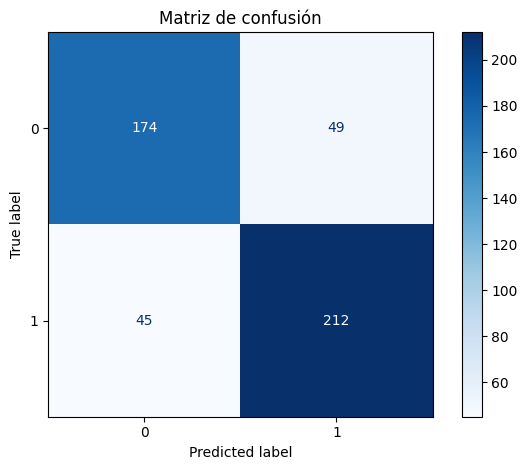


Primeros 10 features por importancia:
alcohol                 0.210463
sulphates               0.134566
volatile acidity        0.128203
total sulfur dioxide    0.114606
density                 0.083716
pH                      0.066618
chlorides               0.061033
fixed acidity           0.055157
citric acid             0.051419
residual sugar          0.049244
dtype: float64


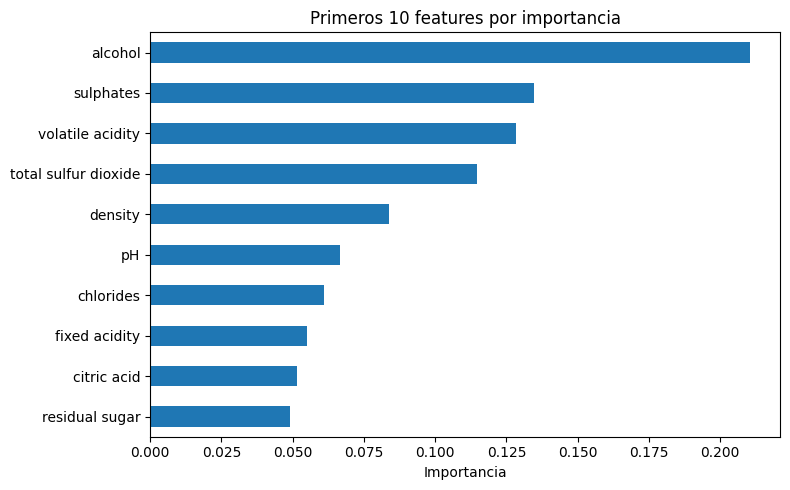


Gradient Boosting finalizado.



In [40]:
if EJECUTAR_GRADIENT_BOOSTING:
  importlib.reload(gbm)
  gradient_boosting_model = gbm.GradientBoostingModel(X3_train.copy(), X3_test.copy(), y3_train.copy(), y3_test.copy(), classes3.copy(), class_weights3.copy())
  gradient_boosting_model.procesar()

Importante mejora de performance respecto a los targets multiclase. Simplificar el problema a binario permite al modelo capturar mejor los patrones relevantes en los datos.

Balance entre clases: El modelo logra un desempeño equilibrado en ambas clases, no solo en la mayoritaria. La redefinición del target mitigó los problemas de desbalance y escasa representatividad de las categorías extremas.

Mayor complejidad del modelo: A diferencia de los escenarios anteriores, el mejor modelo tolera árboles más profundos. Con un target más claro y menos ruidoso, el modelo puede estimar mejor y no caer en sobreajuste.

Conclusiones de Gradient Boosting:

Al agrupar categorías el modelo mejoró progresivamente su rendimiento, llegando a un buen resultado en el target binario, lo que confirma que simplificar la definición del problema facilita una predicción más precisa y equilibrada.

---

### XGBoost

Probamos XGBoost en este dataset para evaluar un algoritmo de boosting más avanzado, con optimizaciones en regularización y manejo de desbalance.

Evaluamos XGBoost con el split 1: las categorías como vienen en el dataset (seis categorías: 3, 4, 5, 6, 7, 8).


Comenzando XGBoost ...

Comenzando entrenamiento ...

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits

Entrenamiento finalizado.

Mejores hiperparámetros:
{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 1200, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}

Resultados en test:
   Accuracy: 0.6021
   F1 macro: 0.3963

Classification Report:
              precision    recall  f1-score   support

           3      0.333     0.333     0.333         3
           4      0.077     0.062     0.069        16
           5      0.708     0.701     0.704       204
           6      0.585     0.589     0.587       192
           7      0.469     0.500     0.484        60
           8      0.200     0.200     0.200         5

    accuracy                          0.602       480
   macro avg      0.395     0.398     0.396       480
weighted avg      0.600     0.602     0.601       480



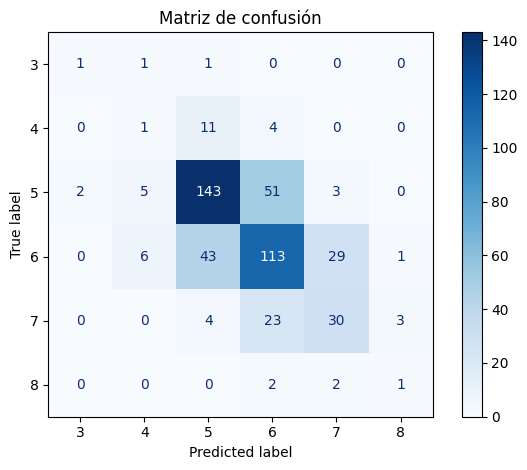


Primeros 10 features por importancia:
alcohol                 0.161557
volatile acidity        0.133987
sulphates               0.117548
density                 0.090078
total sulfur dioxide    0.086336
citric acid             0.072800
free sulfur dioxide     0.071759
residual sugar          0.069960
chlorides               0.067179
pH                      0.064836
dtype: float32


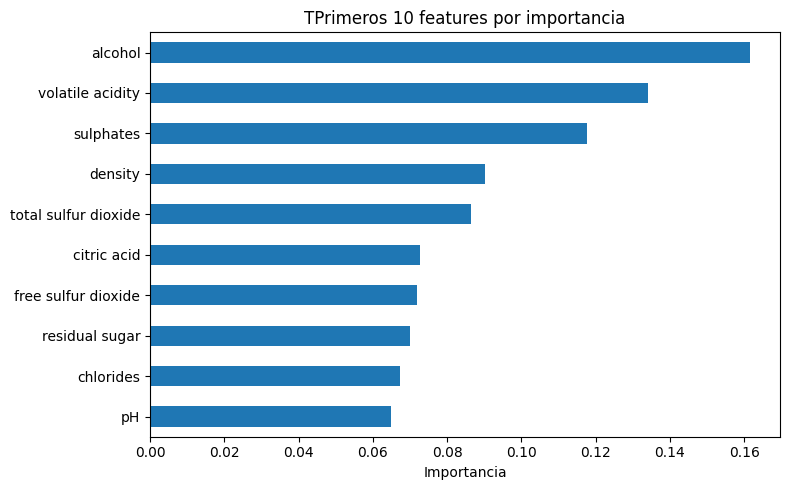


XGBoost finalizado.



In [37]:
if EJECUTAR_XGBOOST:
    importlib.reload(xgbm)
    xgboost_model = xgbm.XGBoostModel(X, y1)
    xgboost_model.procesar()

Accuracy razonable, F1 macro bajo. El modelo logra un accuracy superior al Gradient Boosting estándar.

El F1 macro muestra un pobre equilibrio entre clases: el modelo predice bien las clases mayoritarias (5 y 6), pero prácticamente ignora las minoritarias (3, 4 y 8).

Impacto del desbalance y ruido: XGBoost no consigue mejorar la cobertura de las clases con pocas instancias. El desbalance severo del dataset y la superposición entre calidades cercanas son limitantes importantes, que ni la mayor regularización de XGBoost logra compensar.

Hiperparámetros: El modelo se ajustó mejor con árboles de profundidad moderada y regularización fuerte, lo que muestra que el modelo tiende a evitar sobreajuste. Los estimadores y el learning_rate apuntan a un entrenamiento gradual, necesario para capturar la señal débil presente.

Como vimos en modelos anteriores, el problema central sigue siendo el desbalance y la cercanía entre clases. Incluso modelos avanzados como XGBoost tienen dificultades para mostrar un buen desempeño en este dataset.

Ahora evaluamos XFBoost con el split 2: agrupando las categrías 3 y 4 en una sola (4), las categorías 5 y 6 quedan como están, y agrupando las categorías 7 y 8 en otra (7).


Comenzando XGBoost ...

Comenzando entrenamiento ...

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits

Entrenamiento finalizado.

Mejores hiperparámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 400, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 1.0}

Resultados en test:
   Accuracy: 0.6833
   F1 macro: 0.5365

Classification Report:
              precision    recall  f1-score   support

           4      0.167     0.053     0.080        19
           5      0.751     0.740     0.746       204
           6      0.650     0.688     0.668       192
           7      0.629     0.677     0.652        65

    accuracy                          0.683       480
   macro avg      0.549     0.539     0.536       480
weighted avg      0.671     0.683     0.676       480



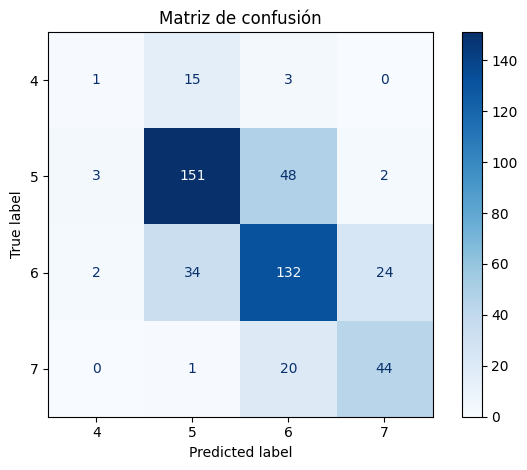


Primeros 10 features por importancia:
alcohol                 0.162296
sulphates               0.121192
volatile acidity        0.116923
total sulfur dioxide    0.089234
residual sugar          0.081735
citric acid             0.079562
pH                      0.073733
density                 0.071526
chlorides               0.070291
fixed acidity           0.068100
dtype: float32


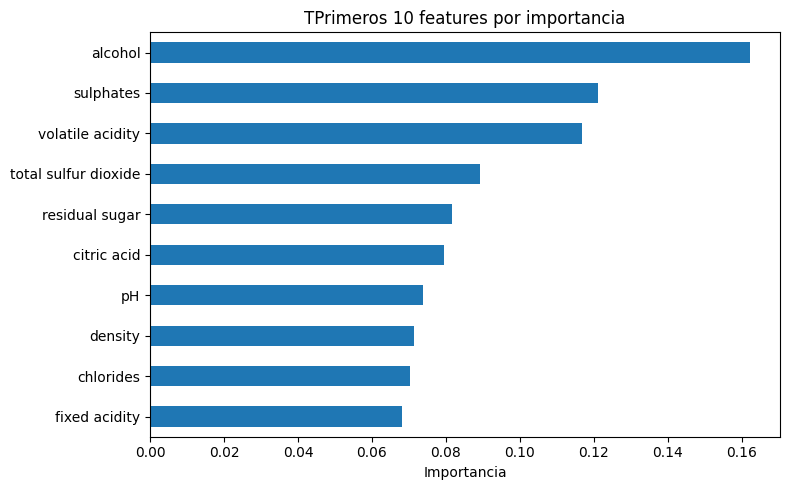


XGBoost finalizado.



In [38]:
if EJECUTAR_XGBOOST:
    importlib.reload(xgbm)
    xgboost_model = xgbm.XGBoostModel(X, y2)
    xgboost_model.procesar()

Interpretación de los resultados. El reagrupamiento de clases reduce la confusión y el desbalance, permitiendo un desempeño más estable y balanceado.

Balance entre clases: El incremento en F1 macro indica que el modelo logra una mejor cobertura en las clases menos representadas, aunque la brecha con las mayoritarias aún existe.

Hiperparámetros: La configuración óptima utiliza árboles más profundos, lo que le permite capturar interacciones más complejas en un target simplificado. Con menos clases, el modelo tolera mejor mayor profundidad y menor regularización, sin caer en sobreajuste.

---

### Conclusiones:

El análisis demuestra que la mayor eficacia predictiva del modelo se alcanza al simplificar la clasificación en dos grupos estratégicos: gama media-baja y gama media-alta.

Este enfoque binario ofrece una guía clara para la toma de decisiones:

-Los vinos clasificados como gama media-baja pueden ser destinados al mercado masivo con una estrategia de precio popular.

-Aquellos identificados como gama media-alta son candidatos que justifican la inversión en una evaluación experta por parte de un sommelier, con el fin de confirmar su potencial para competir en el segmento premium.

---